# AI Customer Review Intelligence System 

## Phase 0: Data Understanding and Exploratory Data Analysis

### 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import nltk
from collections import Counter

In [4]:
pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv("../data/Reviews.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


### 2. Dataset Overview

In [6]:
# Basic Dataset Info
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (568454, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


### 3. Missing Value Analysis

In [7]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

### 4. Class Distribution Analysis

In [8]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

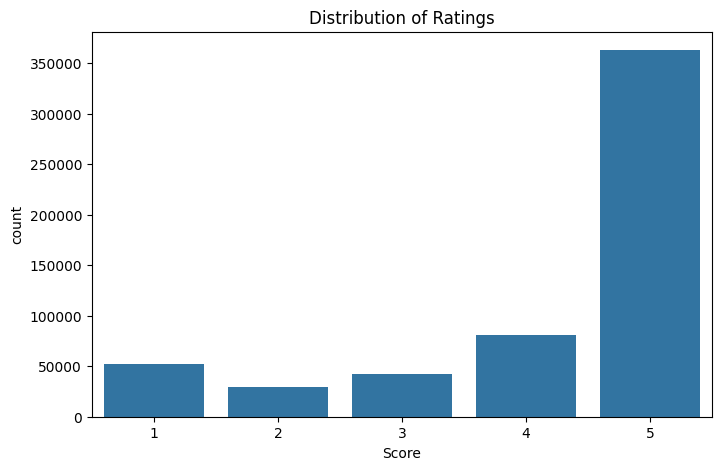

In [9]:
# visualizing
plt.figure(figsize=(8,5))
sns.countplot(x='Score', data=df)
plt.title("Distribution of Ratings")
plt.show()

## Text Inspection

In [10]:
# sample review
df['Text'].iloc[0]

'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [11]:
# run a few (5)
for i in range(5):
    print(df['Text'].iloc[i])
    print("\n---\n")

I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

---

Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".

---

This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.

---

If you are lookin

### 5. Review Length Analysis

In [12]:
df['review_length'] = df['Text'].apply(lambda x: len(x.split()))
df['review_length'].describe()

count    568454.000000
mean         80.264023
std          79.455384
min           3.000000
25%          33.000000
50%          56.000000
75%          98.000000
max        3432.000000
Name: review_length, dtype: float64

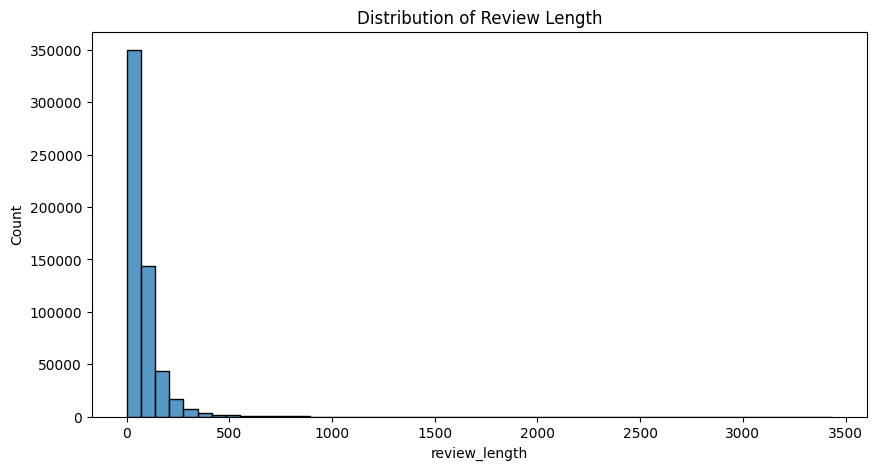

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['review_length'], bins=50)
plt.title("Distribution of Review Length")
plt.show()

### 6. Noise Detection (HTML, URLs, Duplicates)

In [14]:
import re

# Check for HTML tags
html_count = df['Text'].apply(lambda x: bool(re.search(r'<.*?>', x))).sum()
print("Number of reviews containing HTML tags:", html_count)

# Check for URLs
url_count = df['Text'].apply(lambda x: bool(re.search(r'http[s]?://', x))).sum()
print("Number of reviews containing URLs:", url_count)

# check for duplicates
duplicate_count = df.duplicated(subset=['Text']).sum()
print("Duplicate reviews:", duplicate_count)

Number of reviews containing HTML tags: 147324
Number of reviews containing URLs: 11679
Duplicate reviews: 174875


## 7. Data Cleaning and Preprocessing Strategy

Based on exploratory analysis, we identified:

- Significant presence of HTML tags (~25%)
- Presence of URLs (~11k reviews)
- Large number of duplicate reviews (~30%)

In this section, we:
- Remove duplicate reviews
- Clean HTML tags
- Remove URLs
- Standardize text format
- Prepare dataset for sentiment label engineering

### 7.1 Removing Duplicate Reviews

Duplicate reviews can bias model training and inflate performance.
We remove duplicates based on review text to ensure each review is unique.

In [15]:
print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates(subset=['Text'])

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (568454, 11)
Shape after removing duplicates: (393579, 11)


### 7.2 Sentiment Label Engineering

We convert the review score into sentiment classes:

- Score 1–2 → Negative
- Score 3 → Neutral
- Score 4–5 → Positive

This transforms the problem into a 3-class sentiment classification task.

In [16]:
def map_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiment'] = df['Score'].apply(map_sentiment)

df['Sentiment'].value_counts()

Sentiment
Positive    306758
Negative     57067
Neutral      29754
Name: count, dtype: int64

### 7.3 Text Cleaning

We perform the following preprocessing steps:

- Remove HTML tags
- Remove URLs
- Convert text to lowercase
- Remove special characters
- Standardize whitespace

This ensures clean and consistent input for feature engineering.

In [17]:
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning
df['Cleaned_Text'] = df['Text'].apply(clean_text)

df[['Text', 'Cleaned_Text']].head()

,Text,Cleaned_Text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


### 7.4 Final Dataset Preparation

We:
- Select relevant columns
- Reduce dataset size for efficient experimentation
- Prepare final dataframe for modeling

In [18]:
# Keep only relevant columns
df_final = df[['Cleaned_Text', 'Sentiment']].copy()

print("Shape before sampling:", df_final.shape)

# Stratified sampling to preserve class distribution
df_sampled = df_final.groupby('Sentiment', group_keys=False).apply(
    lambda x: x.sample(frac=0.4, random_state=42)
)

print("Shape after sampling:", df_sampled.shape)

df_sampled['Sentiment'].value_counts()

Shape before sampling: (393579, 2)
Shape after sampling: (157432, 2)


C:\Users\Dell\AppData\Local\Temp\ipykernel_18600\2663749340.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_final.groupby('Sentiment', group_keys=False).apply(


Sentiment
Positive    122703
Negative     22827
Neutral      11902
Name: count, dtype: int64

### 7.5 Saving Cleaned Dataset

We save the cleaned and sampled dataset for modeling.
This ensures reproducibility and separation of preprocessing from modeling.

In [19]:
df_sampled.to_csv("../data/cleaned_reviews.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
